# Historical VaR — Market Risk Analysis
**Objective**: Compute the Historical Value at Risk (VaR) at 95% and 99% confidence levels on a French equity portfolio.

**Method**: Historical VaR based on observed daily returns over 3 years.

**Assets**: BNP Paribas, Airbus, TotalEnergies

In [1]:
!pip install yfinance pandas matplotlib seaborn

  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'done'
   ---------------------------------------- 0.0/1.6 MB ? eta -:--:--
   ---------------------------------------- 1.6/1.6 MB 7.6 MB/s  0:00:00
  Created wheel for multitasking: filename=multitasking-0.0.12-py3-none-any.whl size=15702 sha256=4ba51a913f47faf28b4f0fc5b1cd878ffa45ff72576b75cf93a015c0e72410bb
  Stored in directory: c:\users\raniy\appdata\local\pip\cache\wheels\1e\df\0f\e2bbb22d689b30c681feb5410ab64a2523437b34c8ecfc6476
Successfully built multitasking

   ---------------------------------------- 0/5 [peewee]
   ---------------------------------------- 0/5 [peewee]
   ---------------- ----------------------- 2/5 [websockets]
   ---------------- --------

In [2]:
# Imports
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
# Download historical price data
tickers = ["BNP.PA", "CS.PA", "SCR.PA"]

data = yf.download(tickers, start="2022-01-01", end="2025-12-31")["Close"]

print(data.shape)
print(data.head())

[*********************100%***********************]  3 of 3 completed

(1022, 3)
Ticker         BNP.PA      CS.PA     SCR.PA
Date                                       
2022-01-03  45.376587  20.909561  21.501989
2022-01-04  46.896557  21.308027  21.501989
2022-01-05  46.955868  21.343534  22.012835
2022-01-06  47.593517  21.552631  21.827076
2022-01-07  47.823364  21.674931  21.796114


In [6]:
# Calculate daily returns
returns = data.pct_change().dropna()

print(f"Number of daily returns: {len(returns)}")
print(returns.head())
print(returns.describe())

Number of daily returns: 1021
Ticker        BNP.PA     CS.PA    SCR.PA
Date                                    
2022-01-04  0.033497  0.019057  0.000000
2022-01-05  0.001265  0.001666  0.023758
2022-01-06  0.013580  0.009797 -0.008439
2022-01-07  0.004829  0.005674 -0.001419
2022-01-10 -0.007752 -0.002366  0.006747
Ticker       BNP.PA        CS.PA       SCR.PA
count   1021.000000  1021.000000  1021.000000
mean       0.000731     0.000756     0.000539
std        0.017962     0.013603     0.022090
min       -0.101071    -0.078491    -0.245587
25%       -0.007775    -0.006050    -0.009752
50%        0.001672     0.001479     0.000701
75%        0.010749     0.008406     0.011197
max        0.099540     0.078662     0.096680


In [7]:
# Calculate Historical VaR at 95% and 99%
confidence_levels = [0.95, 0.99]

var_results = {}

for ticker in returns.columns:
    var_results[ticker] = {
        "VaR 95%": returns[ticker].quantile(1 - 0.95),
        "VaR 99%": returns[ticker].quantile(1 - 0.99)
    }

var_df = pd.DataFrame(var_results).T
print(var_df)

         VaR 95%   VaR 99%
BNP.PA -0.027942 -0.051791
CS.PA  -0.020397 -0.043072
SCR.PA -0.029330 -0.059116


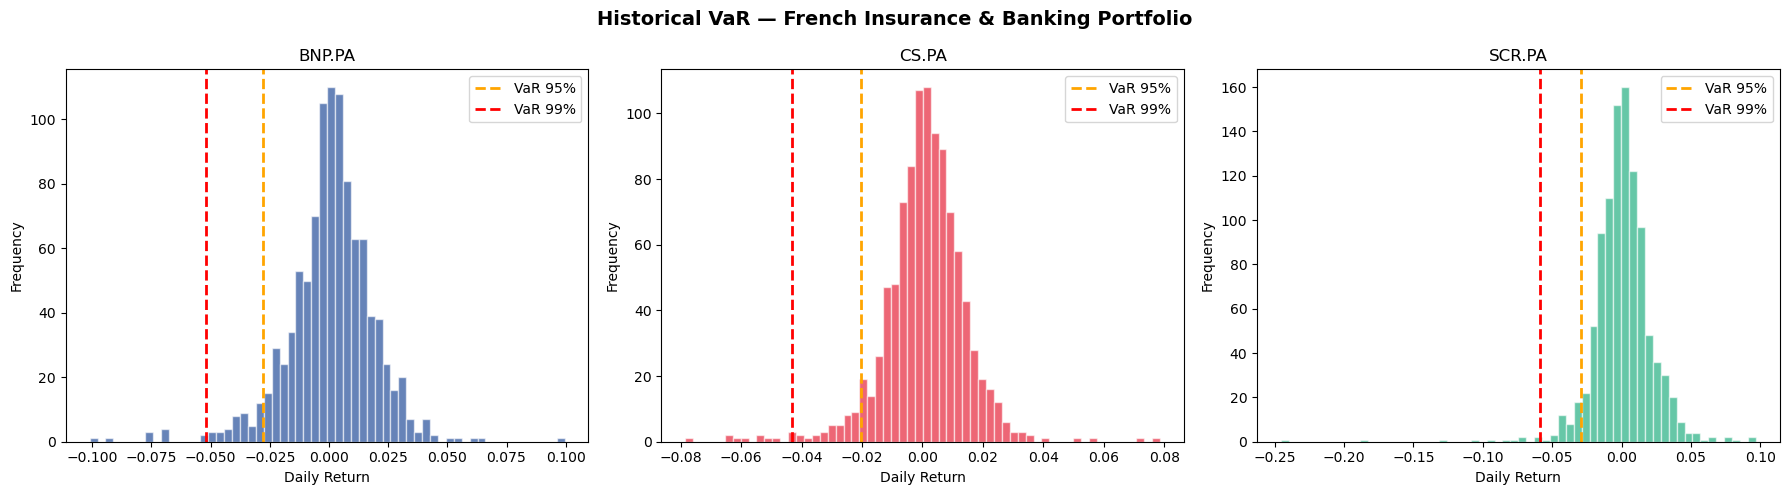

In [8]:
# Visualization — Daily returns distribution with VaR
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Historical VaR — French Insurance & Banking Portfolio", fontsize=14, fontweight="bold")

colors = ["#003189", "#E2001A", "#00A36C"]  # BNP blue, AXA red, SCOR green

for i, ticker in enumerate(returns.columns):
    ax = axes[i]
    
    # Histogram of returns
    ax.hist(returns[ticker], bins=60, color=colors[i], alpha=0.6, edgecolor="white")
    
    # VaR lines
    ax.axvline(var_df.loc[ticker, "VaR 95%"], color="orange", linestyle="--", linewidth=2, label="VaR 95%")
    ax.axvline(var_df.loc[ticker, "VaR 99%"], color="red", linestyle="--", linewidth=2, label="VaR 99%")
    
    ax.set_title(ticker)
    ax.set_xlabel("Daily Return")
    ax.set_ylabel("Frequency")
    ax.legend()

plt.tight_layout()
plt.savefig("VaR_Historique.png", dpi=150)
plt.show()

In [9]:
# Final summary
print("=" * 50)
print("HISTORICAL VAR SUMMARY")
print("Portfolio: BNP Paribas | AXA | SCOR")
print("Period: 2022-01-01 to 2025-12-31")
print("=" * 50)

for ticker in returns.columns:
    var95 = var_df.loc[ticker, "VaR 95%"]
    var99 = var_df.loc[ticker, "VaR 99%"]
    print(f"\n{ticker}")
    print(f"  VaR 95% : {var95:.2%} → on a 1-day loss exceeding this only 5% of the time")
    print(f"  VaR 99% : {var99:.2%} → on a 1-day loss exceeding this only 1% of the time")

print("\n" + "=" * 50)
print("Most risky asset  :", var_df["VaR 99%"].idxmin())
print("Least risky asset :", var_df["VaR 99%"].idxmax())

HISTORICAL VAR SUMMARY
Portfolio: BNP Paribas | AXA | SCOR
Period: 2022-01-01 to 2025-12-31

BNP.PA
  VaR 95% : -2.79% → on a 1-day loss exceeding this only 5% of the time
  VaR 99% : -5.18% → on a 1-day loss exceeding this only 1% of the time

CS.PA
  VaR 95% : -2.04% → on a 1-day loss exceeding this only 5% of the time
  VaR 99% : -4.31% → on a 1-day loss exceeding this only 1% of the time

SCR.PA
  VaR 95% : -2.93% → on a 1-day loss exceeding this only 5% of the time
  VaR 99% : -5.91% → on a 1-day loss exceeding this only 1% of the time

Most risky asset  : SCR.PA
Least risky asset : CS.PA
